02_02. Molecule-level UMAP of the PacBio atlas

Load the molecule-level preprocessed all-samples object, normalize, select highly variable molecules, scale, run PCA, build the neighbor graph, and embed with UMAP colored by broad cell class.

In [1]:
import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)

import os
_r = os.path.abspath(".")
while _r != os.path.dirname(_r) and not os.path.exists(os.path.join(_r, ".notebooks_root")):
    _r = os.path.dirname(_r)
os.chdir(_r if os.path.exists(os.path.join(_r, ".notebooks_root")) else "/oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks")  # cd to notebooks/ root (marked .notebooks_root); relocation-proof

import os, gc
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib
import matplotlib.pyplot as plt
gc.enable()

sc.settings.verbosity = 1
sc.settings.figdir = "figures"
os.makedirs("figures", exist_ok=True)

BASEDIR = "./../pacbio"
H5AD_DIR = f"{BASEDIR}/h5ads"
INFILE = f"{H5AD_DIR}/all_samples_pacbio_recollapsed_raw_counts_pbids_bc_anndata_preprocessed.h5ad"

# Parameters
N_TOP_GENES  = 2000
RANDOM_STATE = 0

# Plot formatting
TICK_LEN = 2.0
TICK_LABEL_PAD = 1.5
AXIS_LABEL_PAD = 1.5
PANEL_TITLE_PAD = 3.0   # pass explicitly: ax.set_title(..., pad=PANEL_TITLE_PAD)
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42
matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = ["Arial"] + matplotlib.rcParams["font.sans-serif"]
plt.rcParams.update({
    "font.size": 6, "axes.titlesize": 6, "axes.labelsize": 6,
    "xtick.labelsize": 6, "ytick.labelsize": 6,
    "legend.fontsize": 6, "legend.title_fontsize": 6, "figure.titlesize": 6,
    "legend.labelspacing": 0.1, "legend.borderpad": 0.3, "legend.handletextpad": 0.2,
    "axes.labelweight": "bold", "axes.titleweight": "bold", "figure.titleweight": "bold",
    "xtick.major.size": TICK_LEN, "ytick.major.size": TICK_LEN,
    "xtick.major.pad": TICK_LABEL_PAD, "ytick.major.pad": TICK_LABEL_PAD,
    "axes.labelpad": AXIS_LABEL_PAD,
})

# reload figure_paths: a live kernel caches FIG_MAP
import importlib
import figure_paths
importlib.reload(figure_paths)
from figure_paths import figpath  # routes figures/ -> figures/figureN/ via FIG_MAP


In [2]:
# 1. Load the molecule-level preprocessed object (.X = raw counts)
adata = sc.read_h5ad(INFILE)
print(f"Loaded: {adata.shape[0]} cells x {adata.shape[1]} molecules")
print("obs available:", [c for c in ["broad_cell_class","cell_ontology_class","tissue","donor"] if c in adata.obs.columns])
adata.layers["counts"] = adata.X.copy()   # keep raw counts
gc.collect()

Loaded: 203311 cells x 854410 molecules
obs available: ['broad_cell_class', 'cell_ontology_class', 'tissue', 'donor']


31

In [3]:
# 2. Library-size normalize + log1p. (Per-feature min-cell filtering is applied
#    upstream in 01_08, so no feature filter is needed here.)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
gc.collect()

27

In [4]:
# 3. Highly variable molecule selection (Seurat flavor on lognorm data), then subset.
sc.pp.highly_variable_genes(adata, n_top_genes=N_TOP_GENES, flavor="seurat", batch_key="tube_id")
print(f"Highly variable molecules: {int(adata.var['highly_variable'].sum())}")
adata = adata[:, adata.var["highly_variable"]].copy()
print(f"Subset to HVG: {adata.shape}")
gc.collect()

Highly variable molecules: 2000
Subset to HVG: (203311, 2000)


23817

In [5]:
# 4. Scale (unit variance, clip at 10).
sc.pp.scale(adata, max_value=10)
gc.collect()

/home/groups/quake/mmantri/miniconda3/envs/python3.12/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


7

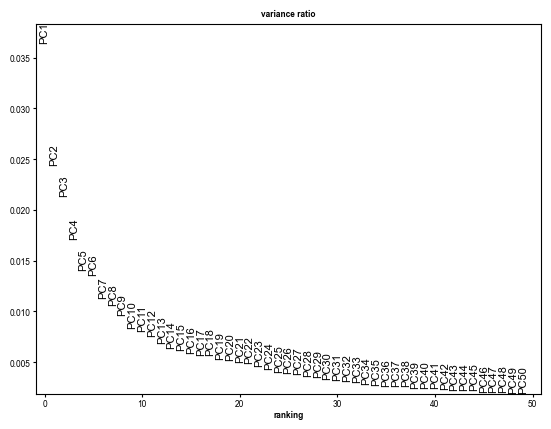

In [6]:
# 5. PCA
sc.tl.pca(adata, n_comps=50, svd_solver="arpack", random_state=RANDOM_STATE)
sc.pl.pca_variance_ratio(adata, n_pcs=50, show=False, log = False)
plt.savefig(figpath("02_02_pca_variance_ratio.pdf"), bbox_inches="tight", dpi=300)
plt.show()

In [7]:
# 6. Neighbor graph + UMAP
sc.pp.neighbors(adata, n_pcs=30, random_state=RANDOM_STATE)
sc.tl.umap(adata, random_state=RANDOM_STATE)
gc.collect()

62036

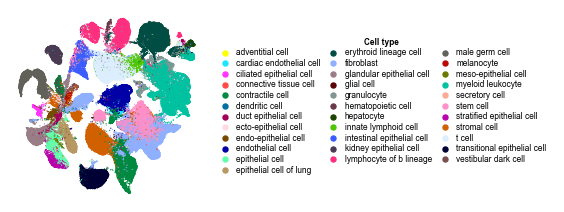

In [8]:
# 7. UMAP colored by broad cell class (preferred formatting)
fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))
sc.pl.umap(
    adata, color="broad_cell_class", legend_loc="right margin",
    size=3, frameon=False, show=False, ax=ax, title="",
)
# Rasterize the scatter points (keeps legend/text/axes as vector)
for coll in ax.collections:
    coll.set_rasterized(True)
plt.legend(ncol=3, prop={'size': 6}, handletextpad=0.4,
           markerscale = 0.6, frameon = False, borderpad=1, 
           columnspacing=0.5,
           labelspacing = 0.2, loc = 6, 
           bbox_to_anchor = (1.0,0.5), 
           title = "Cell type", 
          title_fontproperties={'weight':'bold'})
plt.savefig(figpath("02_02_umap_broad_cell_class.pdf"), bbox_inches="tight", dpi=1200)
plt.show()

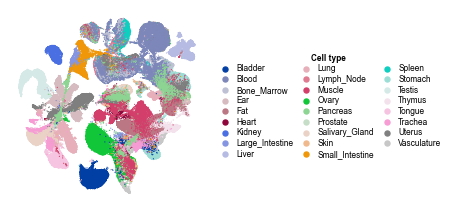

In [9]:
# 7. UMAP colored by broad cell class (preferred formatting)
fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))
sc.pl.umap(
    adata, color="tissue", legend_loc="right margin",
    size=3, frameon=False, show=False, ax=ax, title="",
)
# Rasterize the scatter points (keeps legend/text/axes as vector)
for coll in ax.collections:
    coll.set_rasterized(True)
plt.legend(ncol=3, prop={'size': 6}, handletextpad=0.4,
           markerscale = 0.6, frameon = False, borderpad=1, 
           columnspacing=0.5,
           labelspacing = 0.2, loc = 6, 
           bbox_to_anchor = (1.0,0.5), 
           title = "Cell type", 
          title_fontproperties={'weight':'bold'})
plt.savefig(figpath("02_02_umap_tissue.pdf"), bbox_inches="tight", dpi=1200)
plt.show()

In [ ]:
# 8. Save the embedded object (HVG features + PCA/UMAP/graph)
# OUT = f"{H5AD_DIR}/all_samples_pacbio_recollapsed_molecules_umap_broad_cell_class.h5ad"
# adata.write_h5ad(OUT)
# print("Saved:", OUT)